1. **Creating a Custom Dataset for your files**

    A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. Take a look at this implementation; the SatelliteImageClassification images are stored in a directory img_dir, and their labels are stored separately in a CSV file annotations_file.

    ```
    __init__
    ```
    The \__init__ function is run once when instantiating the Dataset object. We initialize the annotations file, and both transforms


    ```
    __len__
    ```
    The \__len__ function returns the number of samples in our dataset.


    ```
    __getitem__
    ```
    The \__getitem__ function loads and returns a sample from the dataset at the given index idx. Based on the index, it identifies the image’s location on disk, converts that to a tensor using read_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable), and returns the tensor image and corresponding label in a tuple.

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class CustomImageDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_id = os.listdir(img_dir)

        self.transform = transform

    def __len__(self):
        return len(self.img_id)

    def __getitem__(self, idx):
        img_path =  os.path.join(self.img_dir, self.img_id[idx])
        mask_path = os.path.join(self.mask_dir, self.img_id[idx])

        # Load image
        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        # Convert to black and white
        thresh = 128
        fn = lambda x: 255 if x > thresh else 0
        mask = mask.convert('L').point(fn,mode='1')

        if self.transform:
            image, mask = self.transform(image, mask)
        return image, mask

    - Preparing your data for training with DataLoaders

In [ ]:
import torchvision.transforms.v2 as transforms
import numpy as np
import torch

transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    ])

train_img_dir = './RetinaBloodVessel/train/image'
train_mask_dir = './RetinaBloodVessel/train/mask'

val_img_dir = './RetinaBloodVessel/val/image'
val_mask_dir = './RetinaBloodVessel/val/mask'


train_dataset = CustomImageDataset(train_img_dir, train_mask_dir, transform=transform)
valid_dataset = CustomImageDataset(val_img_dir, val_mask_dir, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=8, shuffle=False, num_workers=0)

    - Show sample image from the DataLoader

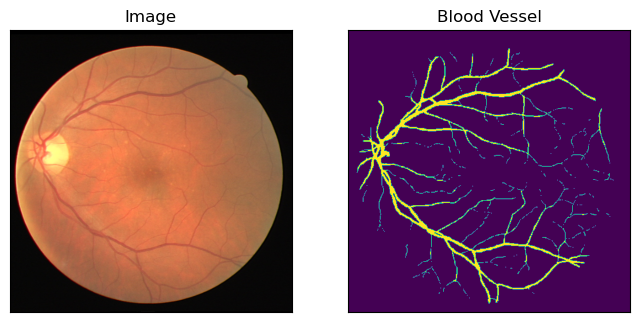

In [ ]:
import matplotlib.pyplot as plt

# helper function for data visualization
def visualize(**images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=(8, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()

image, mask = train_dataset[0] # get some sample
image, mask = image.numpy(), mask.numpy()
image, mask = image.transpose(1, 2, 0), mask.transpose(1, 2, 0)
visualize(
    image=image,
    blood_vessel=mask,
)

2. Define a Convolutional Neural Network

In [ ]:
import torch
import numpy as np
import segmentation_models_pytorch as smp
from segmentation_models_pytorch import utils

ENCODER = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = ['blood_vessel']
ACTIVATION = 'sigmoid' # could be None for logits or 'softmax2d' for multiclass segmentation
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# create segmentation model with pretrained encoder
model = smp.FPN(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    classes=len(CLASSES),
    activation=ACTIVATION,
)



3. Define a Loss function and optimizer

In [ ]:
# create epoch runners
# it is a simple loop of iterating over dataloader`s samples

loss = utils.losses.DiceLoss()
optimizer = torch.optim.Adam([
    dict(params=model.parameters(), lr=0.0001),
])

metrics = [
    utils.metrics.IoU(threshold=0.5),
]

train_epoch = smp.utils.train.TrainEpoch(
    model,
    loss=loss,
    metrics=metrics,
    optimizer=optimizer,
    device=DEVICE,
    verbose=True,
)

valid_epoch = smp.utils.train.ValidEpoch(
    model,
    loss=loss,
    metrics=metrics,
    device=DEVICE,
    verbose=True,
)

4. Train the network

In [ ]:
# train model for 40 epochs

max_score = 0
n_epoch = 20

for i in range(n_epoch):

    print('\nEpoch: {}'.format(i))
    train_logs = train_epoch.run(train_loader)
    valid_logs = valid_epoch.run(valid_loader)

    # do something (save model, change lr, etc.)
    # if max_score < valid_logs['iou_score']:
    #     max_score = valid_logs['iou_score']
    #     torch.save(model, './best_model.pth')
    #     print('Model saved!')

    if i == 25:
        optimizer.param_groups[0]['lr'] = 1e-5
        print('Decrease decoder learning rate to 1e-5!')

torch.save(model, './best_model.pth')
print('Model saved!')


Epoch: 0
valid: 100%|██████████| 2/2 [00:00<00:00,  2.85it/s, dice_loss - 0.7989, iou_score - 0.1127]

Epoch: 1
valid: 100%|██████████| 2/2 [00:00<00:00,  2.92it/s, dice_loss - 0.8267, iou_score - 0.09154]

Epoch: 2
valid: 100%|██████████| 2/2 [00:00<00:00,  2.90it/s, dice_loss - 0.7586, iou_score - 0.1394]

Epoch: 3
valid: 100%|██████████| 2/2 [00:00<00:00,  2.93it/s, dice_loss - 0.6815, iou_score - 0.201] 

Epoch: 4
valid: 100%|██████████| 2/2 [00:00<00:00,  2.88it/s, dice_loss - 0.5902, iou_score - 0.2764]

Epoch: 5
valid: 100%|██████████| 2/2 [00:00<00:00,  2.91it/s, dice_loss - 0.5261, iou_score - 0.3294]

Epoch: 6
valid: 100%|██████████| 2/2 [00:00<00:00,  2.89it/s, dice_loss - 0.4867, iou_score - 0.3688]

Epoch: 7
valid: 100%|██████████| 2/2 [00:00<00:00,  2.87it/s, dice_loss - 0.4594, iou_score - 0.3879]

Epoch: 8
valid: 100%|██████████| 2/2 [00:00<00:00,  2.87it/s, dice_loss - 0.4337, iou_score - 0.4146]

Epoch: 9
valid: 100%|██████████| 2/2 [00:00<00:00,  2.90it/s, dice_loss